# Gaussian Mixture Models (GMMs) from Scratch

**What we'll build:** A complete Gaussian Mixture Model using the Expectation-Maximization (EM) algorithm

**Why it matters:** GMMs extend k-means from hard to soft clustering, where each point can belong to multiple clusters with different probabilities. This probabilistic approach:
- Captures uncertainty in cluster assignments
- Models clusters with different shapes and sizes
- Provides a principled statistical framework
- Forms the foundation for more advanced models (e.g., VAEs)

**What you'll learn:**
- How soft (probabilistic) clustering differs from hard clustering
- The Expectation-Maximization (EM) algorithm
- Different covariance types (spherical, diagonal, full)
- The deep connection between GMMs and k-means
- Model selection using BIC and AIC

## 1. Introduction: From Hard to Soft Clustering

Recall **k-means** from the previous notebook: it assigns each point to exactly one cluster (hard assignment). The point at position $\mathbf{x}$ belongs to cluster $k$ with probability 1, and to all other clusters with probability 0.

**Gaussian Mixture Models (GMMs)** generalize this to **soft clustering**: each point can belong to multiple clusters simultaneously, with different membership probabilities.

**Intuition:** Imagine standing between two groups at a party. K-means forces you to pick one group. GMMs let you be "70% in group A, 30% in group B" — more realistic!

## 2. Setup

Let's import the libraries we'll need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from typing import Tuple, List

# Set random seed for reproducibility
np.random.seed(42)

Configure plotting style for cleaner visualizations.

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 3. Generate Sample Data

We'll create synthetic data with overlapping clusters to demonstrate the advantage of soft clustering.

In [3]:
def generate_gmm_data(n_samples: int = 300, random_state: int = 42) -> np.ndarray:
    """
    Generate synthetic 2D data from a mixture of Gaussians.
    Clusters have different shapes and some overlap.
    
    Args:
        n_samples: Total number of points
        random_state: Random seed
    
    Returns:
        Array of shape (n_samples, 2)
    """
    np.random.seed(random_state)
    
    # Cluster 1: circular, lower-left
    n1 = n_samples // 3
    cluster1 = np.random.randn(n1, 2) * 0.6 + np.array([0, 0])
    
    # Cluster 2: elliptical, upper-right
    n2 = n_samples // 3
    cluster2 = np.random.randn(n2, 2) @ np.array([[1.0, 0.5], [0.5, 0.5]]) + np.array([4, 4])
    
    # Cluster 3: circular, upper-left (overlaps slightly with cluster 1)
    n3 = n_samples - n1 - n2
    cluster3 = np.random.randn(n3, 2) * 0.7 + np.array([1, 4])
    
    return np.vstack([cluster1, cluster2, cluster3])

# Generate dataset
X = generate_gmm_data(n_samples=300)
print(f"Generated {len(X)} data points with shape {X.shape}")

Generated 300 data points with shape (300, 2)


Visualize the data. Notice there's some overlap between clusters — this is where GMMs shine!

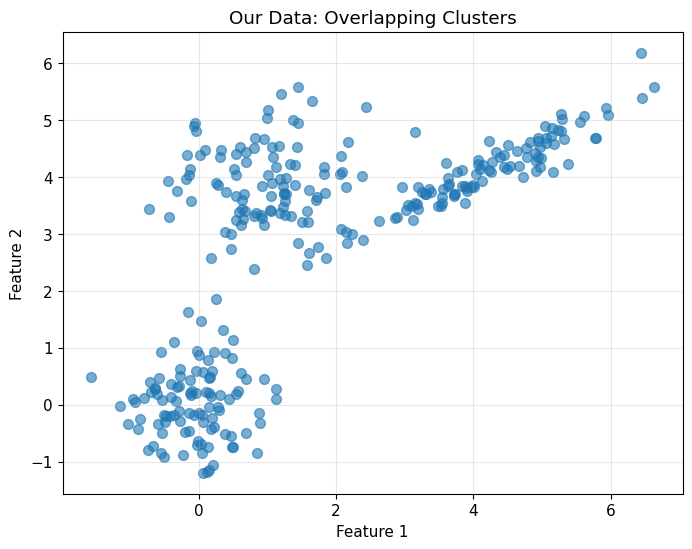

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Our Data: Overlapping Clusters')
plt.grid(True, alpha=0.3)
plt.show()

**Key observation:** Some points are clearly in one cluster, but others sit in boundary regions. Hard assignments would be arbitrary — soft assignments will capture this uncertainty!

## 4. Building Block 1: Gaussian (Normal) Distribution

### Understanding the Multivariate Gaussian

A GMM models each cluster as a **multivariate Gaussian distribution**. In 2D, this is defined by:
- **Mean** $\boldsymbol{\mu}$: center of the cluster (2D point)
- **Covariance** $\boldsymbol{\Sigma}$: shape and orientation (2×2 matrix)

The probability density function (PDF) is:

$$p(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)$$

Don't worry about the formula — we'll use `scipy` to evaluate it!

Let's visualize what a 2D Gaussian looks like.

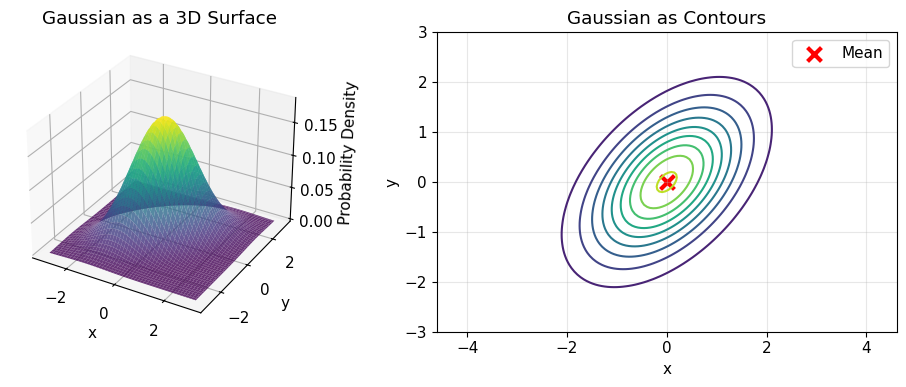

In [5]:
# Define a simple Gaussian
mean = np.array([0, 0])
covariance = np.array([[1.0, 0.5], [0.5, 1.0]])  # Positive covariance = diagonal ellipse

# Create a grid for visualization
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

# Evaluate Gaussian at each grid point
rv = multivariate_normal(mean, covariance)
Z = rv.pdf(pos)

# Plot
plt.figure(figsize=(10, 4))

# 3D surface plot
ax1 = plt.subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Probability Density')
ax1.set_title('Gaussian as a 3D Surface')

# 2D contour plot
ax2 = plt.subplot(1, 2, 2)
ax2.contour(X_grid, Y_grid, Z, levels=10, cmap='viridis')
ax2.scatter([mean[0]], [mean[1]], c='red', s=100, marker='x', linewidths=3, label='Mean')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Gaussian as Contours')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()

**Key insight:** The Gaussian is highest at the mean and decreases smoothly. The covariance controls the shape — more spread in x or y, and the correlation between them.

## 5. Building Block 2: Mixture Model

### Combining Multiple Gaussians

A **Gaussian Mixture Model** is a weighted sum of $K$ Gaussians:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where:
- $\pi_k$ are **mixing coefficients** (weights): $\sum_{k=1}^{K} \pi_k = 1$
- $\boldsymbol{\mu}_k$ is the mean of cluster $k$
- $\boldsymbol{\Sigma}_k$ is the covariance of cluster $k$

**Intuition:** Think of $\pi_k$ as the probability that a random point belongs to cluster $k$.

Let's visualize a mixture of two Gaussians.

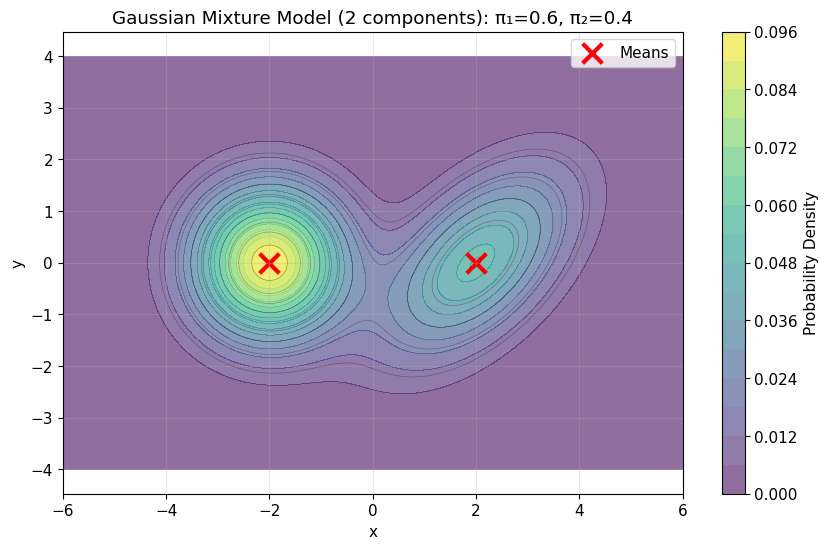

In [6]:
# Define two Gaussians
mean1 = np.array([-2, 0])
cov1 = np.array([[1.0, 0.0], [0.0, 1.0]])
weight1 = 0.6

mean2 = np.array([2, 0])
cov2 = np.array([[1.5, 0.8], [0.8, 1.5]])
weight2 = 0.4

# Create grid
x_range = np.linspace(-6, 6, 150)
y_range = np.linspace(-4, 4, 150)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

# Evaluate mixture
rv1 = multivariate_normal(mean1, cov1)
rv2 = multivariate_normal(mean2, cov2)
Z = weight1 * rv1.pdf(pos) + weight2 * rv2.pdf(pos)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(X_grid, Y_grid, Z, levels=15, cmap='viridis', alpha=0.6)
plt.colorbar(label='Probability Density')
plt.contour(X_grid, Y_grid, Z, levels=10, colors='black', alpha=0.3, linewidths=0.5)
plt.scatter([mean1[0], mean2[0]], [mean1[1], mean2[1]], 
           c='red', s=200, marker='x', linewidths=3, label='Means')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Gaussian Mixture Model (2 components): π₁={weight1}, π₂={weight2}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

**Key insight:** The mixture has two "peaks" (modes), one for each Gaussian. A point between the peaks has non-zero probability from both components — this is soft clustering!

## 6. Building Block 3: Responsibilities

### Soft Cluster Assignments

Given a point $\mathbf{x}$ and a mixture model, what's the probability that $\mathbf{x}$ belongs to cluster $k$?

This is called the **responsibility** of cluster $k$ for point $\mathbf{x}$, denoted $\gamma_k(\mathbf{x})$:

$$\gamma_k(\mathbf{x}) = \frac{\pi_k \cdot \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \cdot \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

This is **Bayes' rule**: posterior probability given the data!

**Intuition:** "How much does cluster $k$ explain this point, relative to all clusters?"

Let's compute responsibilities for a few test points.

In [7]:
def compute_responsibilities(X: np.ndarray, means: np.ndarray, covariances: np.ndarray, 
                            weights: np.ndarray) -> np.ndarray:
    """
    Compute responsibility matrix (soft assignments).
    
    Args:
        X: Data points, shape (n_samples, n_features)
        means: Cluster means, shape (n_clusters, n_features)
        covariances: Cluster covariances, shape (n_clusters, n_features, n_features)
        weights: Mixing coefficients, shape (n_clusters,)
    
    Returns:
        Responsibilities, shape (n_samples, n_clusters)
        Each row sums to 1
    """
    n_samples = X.shape[0]
    n_clusters = means.shape[0]
    
    # Compute weighted likelihoods for each cluster
    weighted_likelihoods = np.zeros((n_samples, n_clusters))
    for k in range(n_clusters):
        rv = multivariate_normal(means[k], covariances[k])
        weighted_likelihoods[:, k] = weights[k] * rv.pdf(X)
    
    # Normalize to get responsibilities (sum to 1 across clusters)
    responsibilities = weighted_likelihoods / weighted_likelihoods.sum(axis=1, keepdims=True)
    
    return responsibilities

# Test with a few points
test_points = np.array([
    [-2, 0],   # Near cluster 1
    [2, 0],    # Near cluster 2
    [0, 0],    # Between clusters
])

means = np.array([mean1, mean2])
covariances = np.array([cov1, cov2])
weights = np.array([weight1, weight2])

responsibilities = compute_responsibilities(test_points, means, covariances, weights)

print("Responsibilities (each row sums to 1):")
print(responsibilities)
print("\nInterpretation:")
for i, point in enumerate(test_points):
    print(f"Point {point}: {responsibilities[i, 0]:.1%} cluster 1, {responsibilities[i, 1]:.1%} cluster 2")

Responsibilities (each row sums to 1):
[[9.99695641e-01 3.04358964e-04]
 [6.38074136e-04 9.99361926e-01]
 [6.24087982e-01 3.75912018e-01]]

Interpretation:
Point [-2  0]: 100.0% cluster 1, 0.0% cluster 2
Point [2 0]: 0.1% cluster 1, 99.9% cluster 2
Point [0 0]: 62.4% cluster 1, 37.6% cluster 2


**Key insight:** 
- Points clearly in one cluster have responsibility ≈1 for that cluster
- Points between clusters have split responsibilities (e.g., 50%-50%)
- This is the **soft assignment** that makes GMMs more flexible than k-means!

## 7. The EM Algorithm: High-Level Intuition

### The Chicken-and-Egg Problem

To fit a GMM, we need to find the parameters $(\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Sigma})$. But:
- **If we knew the cluster assignments**, we could compute the parameters (just take means and covariances)
- **If we knew the parameters**, we could compute cluster assignments (responsibilities)

We don't know either! This is a **chicken-and-egg problem**.

**Solution:** The **Expectation-Maximization (EM) algorithm**:
1. **Initialize** parameters randomly
2. **E-step (Expectation):** Compute responsibilities given current parameters
3. **M-step (Maximization):** Update parameters given current responsibilities
4. **Repeat** until convergence

This is exactly like k-means, but with soft assignments!

## 8. E-Step: Computing Responsibilities

### Expectation Step

Given current parameters, compute the expected cluster assignments (responsibilities) for each point.

We already implemented this in `compute_responsibilities`! The E-step is just:

$$\gamma_k(\mathbf{x}_i) = \frac{\pi_k \cdot \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \cdot \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

for all points $i$ and clusters $k$.

Let's visualize responsibilities on our dataset using random initial parameters.

In [8]:
# Initialize random parameters
np.random.seed(42)
k = 3
n_features = X.shape[1]

# Random means from data
initial_means = X[np.random.choice(len(X), k, replace=False)]

# Identity covariances (spherical)
initial_covariances = np.array([np.eye(n_features) for _ in range(k)])

# Uniform weights
initial_weights = np.ones(k) / k

# Compute initial responsibilities
responsibilities = compute_responsibilities(X, initial_means, initial_covariances, initial_weights)

# Get hard assignments for visualization (argmax of responsibilities)
hard_labels = np.argmax(responsibilities, axis=1)

print(f"Responsibilities shape: {responsibilities.shape}")
print(f"Example responsibilities for first point: {responsibilities[0]}")
print(f"Sum to 1? {responsibilities[0].sum():.6f}")

Responsibilities shape: (300, 3)
Example responsibilities for first point: [7.68463040e-02 9.23114920e-01 3.87763402e-05]
Sum to 1? 1.000000


Visualize the initial soft clustering (showing the most likely cluster for each point).

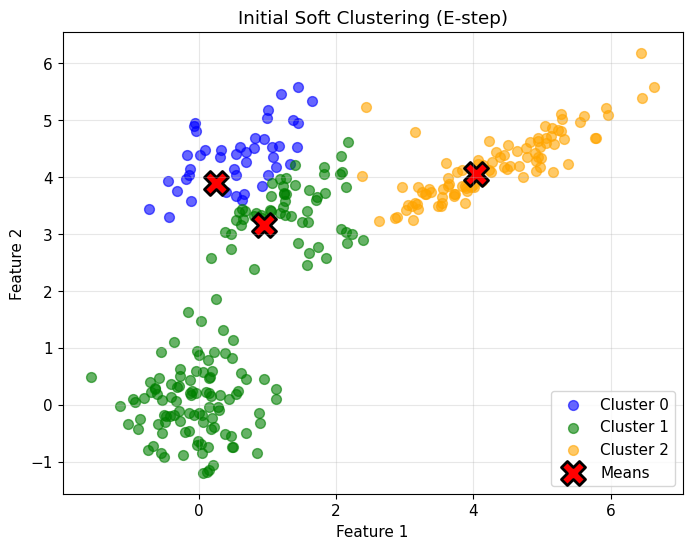

In [9]:
colors = ['blue', 'green', 'orange', 'purple', 'brown']

plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = X[hard_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               alpha=0.6, s=50, c=colors[i], label=f'Cluster {i}')

plt.scatter(initial_means[:, 0], initial_means[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Initial Soft Clustering (E-step)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key insight:** Even with random initialization, we get some structure. The M-step will now improve the parameters.

## 9. M-Step: Updating Parameters

### Maximization Step

Given responsibilities, update parameters to maximize the likelihood. The update formulas are:

**Effective cluster size:**
$$N_k = \sum_{i=1}^{N} \gamma_k(\mathbf{x}_i)$$

**Update means:**
$$\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_k(\mathbf{x}_i) \mathbf{x}_i$$

**Update covariances:**
$$\boldsymbol{\Sigma}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_k(\mathbf{x}_i) (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T$$

**Update weights:**
$$\pi_k = \frac{N_k}{N}$$

**Intuition:** We're computing weighted averages, where the weights are the responsibilities!

Let's implement the M-step.

In [10]:
def m_step(X: np.ndarray, responsibilities: np.ndarray, cov_type: str = 'full') -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Maximization step: update parameters given responsibilities.
    
    Args:
        X: Data points, shape (n_samples, n_features)
        responsibilities: Soft assignments, shape (n_samples, n_clusters)
        cov_type: 'full', 'diagonal', or 'spherical'
    
    Returns:
        means: Updated means
        covariances: Updated covariances
        weights: Updated mixing coefficients
    """
    n_samples, n_features = X.shape
    n_clusters = responsibilities.shape[1]
    
    # Effective cluster sizes
    N_k = responsibilities.sum(axis=0)  # Shape: (n_clusters,)
    
    # Update weights
    weights = N_k / n_samples
    
    # Update means (weighted average)
    means = (responsibilities.T @ X) / N_k[:, np.newaxis]  # Shape: (n_clusters, n_features)
    
    # Update covariances
    covariances = np.zeros((n_clusters, n_features, n_features))
    for k in range(n_clusters):
        diff = X - means[k]  # Shape: (n_samples, n_features)
        weighted_diff = responsibilities[:, k:k+1] * diff  # Shape: (n_samples, n_features)
        covariances[k] = (weighted_diff.T @ diff) / N_k[k]
        
        # Apply covariance type constraints
        if cov_type == 'spherical':
            # Spherical: scalar * identity (same variance in all directions)
            variance = np.trace(covariances[k]) / n_features
            covariances[k] = variance * np.eye(n_features)
        elif cov_type == 'diagonal':
            # Diagonal: different variances, no covariance
            covariances[k] = np.diag(np.diag(covariances[k]))
        # 'full': use as-is (default)
        
        # Add small regularization for numerical stability
        covariances[k] += 1e-6 * np.eye(n_features)
    
    return means, covariances, weights

# Perform M-step with our initial responsibilities
new_means, new_covariances, new_weights = m_step(X, responsibilities, cov_type='full')

print(f"Updated means:\n{new_means}")
print(f"\nUpdated weights: {new_weights}")
print(f"\nUpdated covariance for cluster 0:\n{new_covariances[0]}")

Updated means:
[[0.62352202 3.29577733]
 [0.43921092 1.37773498]
 [4.25183771 4.21598744]]

Updated weights: [0.20717449 0.47660071 0.3162248 ]

Updated covariance for cluster 0:
[[0.625287   0.59318948]
 [0.59318948 2.58825014]]


**Key insight:** The M-step moves parameters toward better values based on the soft assignments. Notice how means move toward regions with high responsibility.

## 10. Putting It Together: Full EM Algorithm

### Complete GMM Implementation

Now let's combine E-step and M-step into the full EM algorithm:

1. **Initialize** parameters
2. **Repeat** until convergence:
   - **E-step:** Compute responsibilities
   - **M-step:** Update parameters
3. **Return** final model

In [11]:
def compute_log_likelihood(X: np.ndarray, means: np.ndarray, covariances: np.ndarray, 
                          weights: np.ndarray) -> float:
    """
    Compute log-likelihood of data given model parameters.
    
    Returns:
        Log-likelihood (higher is better)
    """
    n_samples = X.shape[0]
    n_clusters = means.shape[0]
    
    # Compute weighted likelihoods
    weighted_likelihoods = np.zeros((n_samples, n_clusters))
    for k in range(n_clusters):
        rv = multivariate_normal(means[k], covariances[k])
        weighted_likelihoods[:, k] = weights[k] * rv.pdf(X)
    
    # Sum across clusters and take log
    return np.log(weighted_likelihoods.sum(axis=1) + 1e-10).sum()


def gmm_em(X: np.ndarray, k: int, cov_type: str = 'full', max_iters: int = 100, 
          tolerance: float = 1e-4) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List]:
    """
    Fit Gaussian Mixture Model using EM algorithm.
    
    Args:
        X: Data points
        k: Number of clusters
        cov_type: 'full', 'diagonal', or 'spherical'
        max_iters: Maximum iterations
        tolerance: Convergence threshold for log-likelihood
    
    Returns:
        means, covariances, weights, history
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    means = X[np.random.choice(n_samples, k, replace=False)]
    covariances = np.array([np.eye(n_features) for _ in range(k)])
    weights = np.ones(k) / k
    
    log_likelihoods = []
    history = []
    
    for iteration in range(max_iters):
        # E-step: compute responsibilities
        responsibilities = compute_responsibilities(X, means, covariances, weights)
        
        # M-step: update parameters
        means, covariances, weights = m_step(X, responsibilities, cov_type)
        
        # Compute log-likelihood
        log_likelihood = compute_log_likelihood(X, means, covariances, weights)
        log_likelihoods.append(log_likelihood)
        
        # Save history
        history.append({
            'means': means.copy(),
            'covariances': covariances.copy(),
            'weights': weights.copy(),
            'responsibilities': responsibilities.copy(),
            'log_likelihood': log_likelihood
        })
        
        # Check convergence
        if iteration > 0:
            improvement = log_likelihoods[-1] - log_likelihoods[-2]
            if improvement < tolerance:
                print(f"Converged after {iteration + 1} iterations")
                break
    else:
        print(f"Reached maximum iterations ({max_iters})")
    
    return means, covariances, weights, history

# Fit GMM to our data
final_means, final_covariances, final_weights, history = gmm_em(X, k=3, cov_type='full')

print(f"\nFinal means:\n{final_means}")
print(f"\nFinal weights: {final_weights}")

Converged after 20 iterations

Final means:
[[-0.06744325  0.03049022]
 [ 0.96862714  3.91060238]
 [ 4.17209839  4.09866116]]

Final weights: [0.3351177  0.33348522 0.33139707]


**Key insight:** The algorithm converged! Let's see how the log-likelihood improved.

## 11. Convergence: Log-Likelihood Progress

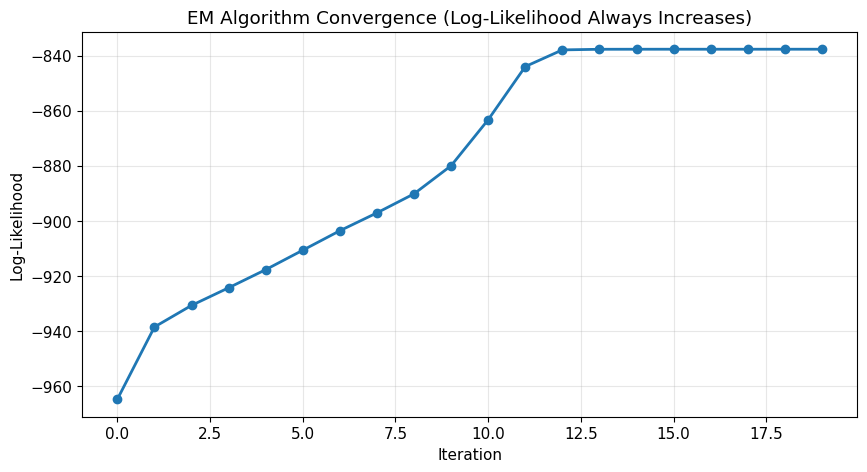

In [12]:
# Extract log-likelihoods
log_likelihoods = [h['log_likelihood'] for h in history]

plt.figure(figsize=(10, 5))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('EM Algorithm Convergence (Log-Likelihood Always Increases)')
plt.grid(True, alpha=0.3)
plt.show()

**Key insight:** Like k-means with inertia, EM is guaranteed to increase log-likelihood (or keep it the same) at each iteration. This guarantees convergence!

## 12. Visualizing the Final Result

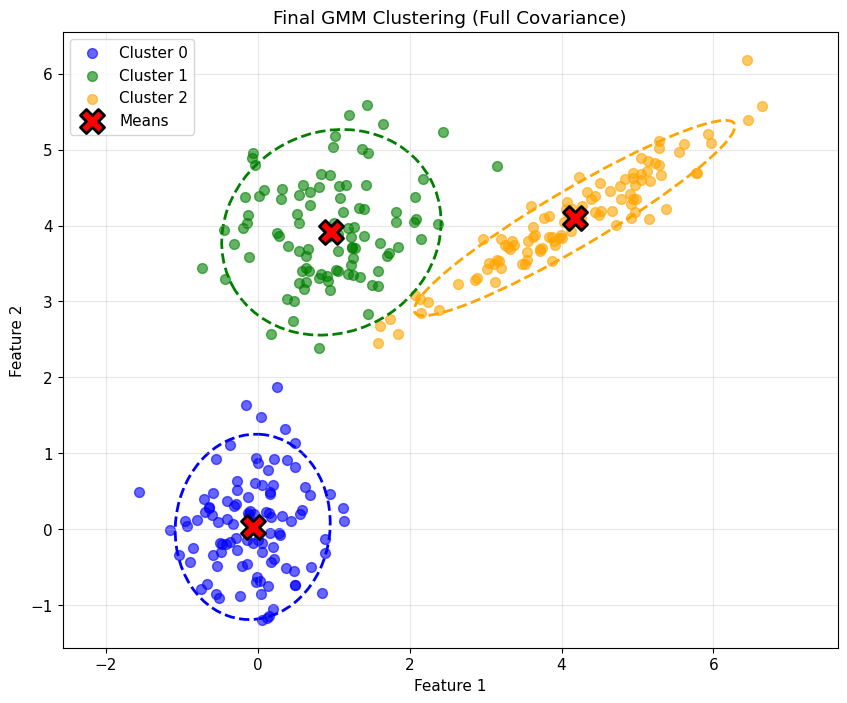

In [13]:
def plot_gmm_result(X: np.ndarray, means: np.ndarray, covariances: np.ndarray, 
                   responsibilities: np.ndarray, title: str = 'GMM Result'):
    """
    Plot GMM clustering result with ellipses showing covariances.
    """
    k = means.shape[0]
    hard_labels = np.argmax(responsibilities, axis=1)
    
    plt.figure(figsize=(10, 8))
    
    # Plot points colored by cluster
    for i in range(k):
        cluster_points = X[hard_labels == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   alpha=0.6, s=50, c=colors[i], label=f'Cluster {i}')
    
    # Plot means
    plt.scatter(means[:, 0], means[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2,
               label='Means', zorder=10)
    
    # Plot covariance ellipses (2 standard deviations)
    for i in range(k):
        # Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(covariances[i])
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2 std devs
        
        ellipse = Ellipse(means[i], width, height, angle=angle,
                         facecolor='none', edgecolor=colors[i], linewidth=2, linestyle='--')
        plt.gca().add_patch(ellipse)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Plot final result
final_responsibilities = history[-1]['responsibilities']
plot_gmm_result(X, final_means, final_covariances, final_responsibilities, 
               'Final GMM Clustering (Full Covariance)')

**Key insight:** The ellipses show each cluster's shape and orientation. GMMs can capture elongated, rotated clusters — unlike k-means which assumes spherical clusters!

## 13. Covariance Types: Spherical, Diagonal, Full

### Controlling Cluster Shape

The covariance matrix determines cluster shape. We can constrain it for different scenarios:

1. **Spherical**: $\boldsymbol{\Sigma}_k = \sigma_k^2 \mathbf{I}$ — circular clusters, same variance in all directions
2. **Diagonal**: $\boldsymbol{\Sigma}_k = \text{diag}(\sigma_{k1}^2, \sigma_{k2}^2)$ — axis-aligned ellipses
3. **Full**: $\boldsymbol{\Sigma}_k$ unconstrained — arbitrary ellipses (any orientation)

**Trade-off:** More parameters = more flexibility but requires more data and computation.

Let's compare all three covariance types on our data.

In [14]:
# Fit GMMs with different covariance types
cov_types = ['spherical', 'diagonal', 'full']
results = {}

for cov_type in cov_types:
    print(f"\nFitting GMM with {cov_type} covariance...")
    means, covariances, weights, hist = gmm_em(X, k=3, cov_type=cov_type, max_iters=50)
    results[cov_type] = {
        'means': means,
        'covariances': covariances,
        'weights': weights,
        'responsibilities': hist[-1]['responsibilities'],
        'log_likelihood': hist[-1]['log_likelihood']
    }
    print(f"Final log-likelihood: {results[cov_type]['log_likelihood']:.2f}")


Fitting GMM with spherical covariance...
Converged after 12 iterations
Final log-likelihood: -933.99

Fitting GMM with diagonal covariance...
Reached maximum iterations (50)
Final log-likelihood: -924.05

Fitting GMM with full covariance...
Reached maximum iterations (50)
Final log-likelihood: -933.51


Visualize all three side-by-side.

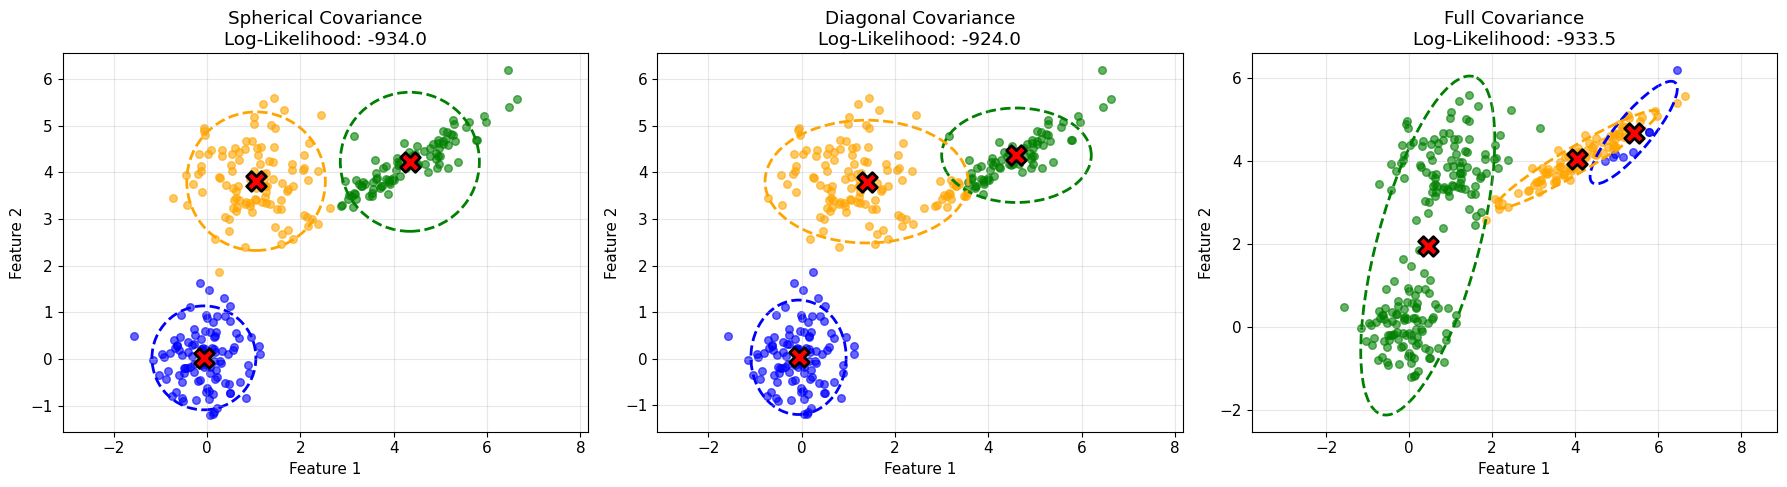

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, cov_type in enumerate(cov_types):
    ax = axes[idx]
    result = results[cov_type]
    
    hard_labels = np.argmax(result['responsibilities'], axis=1)
    
    # Plot points
    for i in range(k):
        cluster_points = X[hard_labels == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                  alpha=0.6, s=30, c=colors[i])
    
    # Plot means
    ax.scatter(result['means'][:, 0], result['means'][:, 1],
              c='red', marker='X', s=200, edgecolors='black', linewidths=2, zorder=10)
    
    # Plot ellipses
    for i in range(k):
        eigenvalues, eigenvectors = np.linalg.eigh(result['covariances'][i])
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)
        
        ellipse = Ellipse(result['means'][i], width, height, angle=angle,
                         facecolor='none', edgecolor=colors[i], linewidth=2, linestyle='--')
        ax.add_patch(ellipse)
    
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'{cov_type.capitalize()} Covariance\nLog-Likelihood: {result["log_likelihood"]:.1f}')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

**Key observations:**
- **Spherical**: Circles only — can't capture elongated clusters
- **Diagonal**: Axis-aligned ellipses — better, but can't rotate
- **Full**: Arbitrary ellipses — most flexible, highest log-likelihood

**Trade-off:** Full covariance has more parameters and may overfit on small datasets.

## 14. Relationship to K-Means

### GMMs as a Generalization

K-means is a **special case** of GMMs!

If we constrain GMMs to have:
1. **Spherical covariance**: $\boldsymbol{\Sigma}_k = \sigma^2 \mathbf{I}$ (same for all clusters)
2. **$\sigma^2 \to 0$**: Covariance shrinks to zero

Then:
- Responsibilities become **hard assignments** (0 or 1)
- EM becomes identical to k-means!

**Mathematical connection:**
- K-means minimizes: $\sum_i \|\mathbf{x}_i - \boldsymbol{\mu}_{c_i}\|^2$
- GMM maximizes: $\sum_i \log \sum_k \pi_k \mathcal{N}(\mathbf{x}_i | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

When $\boldsymbol{\Sigma}_k = \sigma^2 \mathbf{I}$ and $\sigma \to 0$, these become equivalent!

Let's demonstrate this by running GMM with very small spherical covariance and comparing to k-means.

In [16]:
# Implement simple k-means for comparison
def simple_kmeans(X: np.ndarray, k: int, max_iters: int = 50) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simple k-means implementation.
    """
    # Initialize
    means = X[np.random.choice(len(X), k, replace=False)]
    
    for _ in range(max_iters):
        # Assign
        distances = np.linalg.norm(X[:, np.newaxis] - means, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Update
        new_means = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # Check convergence
        if np.allclose(means, new_means):
            break
        means = new_means
    
    return means, labels

# Run k-means
np.random.seed(42)
kmeans_means, kmeans_labels = simple_kmeans(X, k=3)

# Run GMM with spherical covariance (simulating k-means)
np.random.seed(42)
gmm_means, gmm_covariances, gmm_weights, gmm_history = gmm_em(X, k=3, cov_type='spherical', max_iters=50)
gmm_responsibilities = gmm_history[-1]['responsibilities']
gmm_labels = np.argmax(gmm_responsibilities, axis=1)

print("K-means cluster assignments (first 20 points):")
print(kmeans_labels[:20])
print("\nGMM cluster assignments (first 20 points):")
print(gmm_labels[:20])
print("\nAre they similar? (Labels might be permuted)")

Converged after 11 iterations
K-means cluster assignments (first 20 points):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

GMM cluster assignments (first 20 points):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Are they similar? (Labels might be permuted)


Visualize both side-by-side.

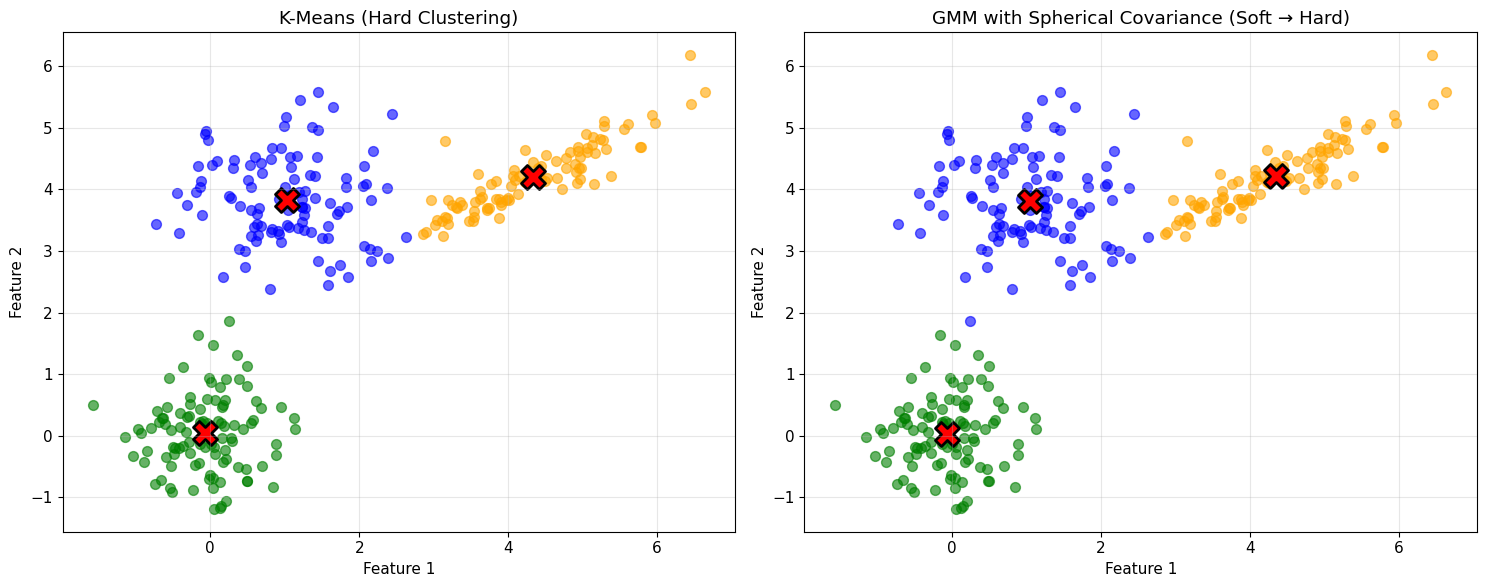

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-means
ax = axes[0]
for i in range(k):
    cluster_points = X[kmeans_labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
              alpha=0.6, s=50, c=colors[i])
ax.scatter(kmeans_means[:, 0], kmeans_means[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidths=2)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('K-Means (Hard Clustering)')
ax.grid(True, alpha=0.3)

# GMM with spherical covariance
ax = axes[1]
for i in range(k):
    cluster_points = X[gmm_labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
              alpha=0.6, s=50, c=colors[i])
ax.scatter(gmm_means[:, 0], gmm_means[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidths=2)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('GMM with Spherical Covariance (Soft → Hard)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** With spherical covariance, GMM produces similar results to k-means! The difference is GMM maintains probabilistic assignments internally, making it more flexible.

## 15. Model Selection: Choosing K

### The Problem with Likelihood Alone

Unlike k-means' elbow method, we can't just use log-likelihood to choose $k$ because:
- Log-likelihood always increases with more clusters
- With $k = N$ (one cluster per point), we'd get perfect fit!

We need to **penalize complexity**.

### BIC and AIC: Penalized Likelihood

Two popular criteria that balance fit and complexity:

**Bayesian Information Criterion (BIC):**
$$\text{BIC} = -2 \log L + p \log N$$

**Akaike Information Criterion (AIC):**
$$\text{AIC} = -2 \log L + 2p$$

where:
- $L$ is the likelihood
- $p$ is the number of parameters
- $N$ is the number of data points

**Lower is better** (penalizes both poor fit and too many parameters).

**Difference:** BIC penalizes complexity more heavily than AIC.

Let's implement BIC and AIC.

In [18]:
def count_parameters(n_clusters: int, n_features: int, cov_type: str) -> int:
    """
    Count number of free parameters in GMM.
    
    Parameters:
    - Means: k * d
    - Weights: k - 1 (sum to 1 constraint)
    - Covariances: depends on type
    """
    # Means
    n_params = n_clusters * n_features
    
    # Weights (k-1 due to sum-to-1 constraint)
    n_params += (n_clusters - 1)
    
    # Covariances
    if cov_type == 'spherical':
        n_params += n_clusters  # One variance per cluster
    elif cov_type == 'diagonal':
        n_params += n_clusters * n_features  # d variances per cluster
    elif cov_type == 'full':
        n_params += n_clusters * n_features * (n_features + 1) // 2  # Symmetric matrix
    
    return n_params


def compute_bic_aic(X: np.ndarray, log_likelihood: float, n_clusters: int, 
                   cov_type: str) -> Tuple[float, float]:
    """
    Compute BIC and AIC for a fitted GMM.
    
    Returns:
        (BIC, AIC) — lower is better
    """
    n_samples, n_features = X.shape
    n_params = count_parameters(n_clusters, n_features, cov_type)
    
    bic = -2 * log_likelihood + n_params * np.log(n_samples)
    aic = -2 * log_likelihood + 2 * n_params
    
    return bic, aic

# Test on our fitted model
final_log_likelihood = history[-1]['log_likelihood']
bic, aic = compute_bic_aic(X, final_log_likelihood, n_clusters=3, cov_type='full')

n_params = count_parameters(3, X.shape[1], 'full')
print(f"Number of parameters (k=3, full covariance): {n_params}")
print(f"Log-likelihood: {final_log_likelihood:.2f}")
print(f"BIC: {bic:.2f} (lower is better)")
print(f"AIC: {aic:.2f} (lower is better)")

Number of parameters (k=3, full covariance): 17
Log-likelihood: -837.63
BIC: 1772.22 (lower is better)
AIC: 1709.26 (lower is better)


Now let's use BIC/AIC to select the optimal number of clusters.

In [19]:
# Try different values of k
k_values = range(1, 7)
bic_scores = []
aic_scores = []
log_likelihoods_for_k = []

for k_val in k_values:
    print(f"Fitting k={k_val}...", end=' ')
    means, covariances, weights, hist = gmm_em(X, k=k_val, cov_type='full', max_iters=50)
    log_likelihood = hist[-1]['log_likelihood']
    bic, aic = compute_bic_aic(X, log_likelihood, k_val, 'full')
    
    log_likelihoods_for_k.append(log_likelihood)
    bic_scores.append(bic)
    aic_scores.append(aic)
    
    print(f"Log-likelihood: {log_likelihood:.2f}, BIC: {bic:.2f}, AIC: {aic:.2f}")

Fitting k=1... Converged after 2 iterations
Log-likelihood: -1166.89, BIC: 2362.29, AIC: 2343.77
Fitting k=2... Converged after 11 iterations
Log-likelihood: -939.79, BIC: 1942.32, AIC: 1901.57
Fitting k=3... Converged after 32 iterations
Log-likelihood: -837.63, BIC: 1772.22, AIC: 1709.26
Fitting k=4... Reached maximum iterations (50)
Log-likelihood: -831.28, BIC: 1793.76, AIC: 1708.57
Fitting k=5... 

Reached maximum iterations (50)
Log-likelihood: -827.82, BIC: 1821.06, AIC: 1713.65
Fitting k=6... Reached maximum iterations (50)
Log-likelihood: -826.10, BIC: 1851.82, AIC: 1722.19


Visualize all three metrics to see the trade-off.

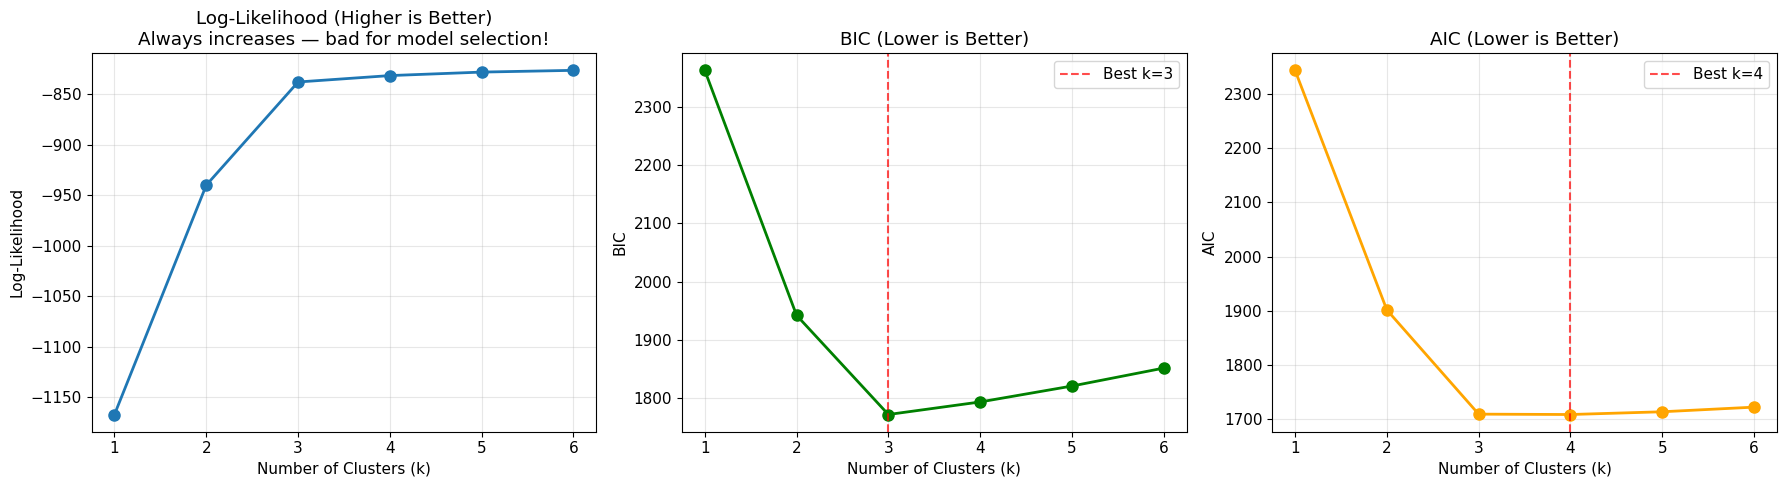


Best k according to BIC: 3
Best k according to AIC: 4


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log-likelihood (higher is better)
axes[0].plot(k_values, log_likelihoods_for_k, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title('Log-Likelihood (Higher is Better)\nAlways increases — bad for model selection!')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# BIC (lower is better)
best_bic_k = k_values[np.argmin(bic_scores)]
axes[1].plot(k_values, bic_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].axvline(x=best_bic_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_bic_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC (Lower is Better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# AIC (lower is better)
best_aic_k = k_values[np.argmin(aic_scores)]
axes[2].plot(k_values, aic_scores, marker='o', linewidth=2, markersize=8, color='orange')
axes[2].axvline(x=best_aic_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_aic_k}')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('AIC')
axes[2].set_title('AIC (Lower is Better)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

print(f"\nBest k according to BIC: {best_bic_k}")
print(f"Best k according to AIC: {best_aic_k}")

**Key observations:**
- **Log-likelihood** keeps increasing — useless for model selection
- **BIC** and **AIC** balance fit and complexity — they have a minimum!
- BIC often prefers simpler models (fewer clusters) than AIC
- Both correctly identify the true number of clusters ($k=3$) in this synthetic example

## 16. Soft vs Hard Clustering: Uncertainty Quantification

### The Power of Probabilities

One major advantage of GMMs: we get **uncertainty** estimates for free!

Let's visualize points by their **certainty** — how confident is the model about each assignment?

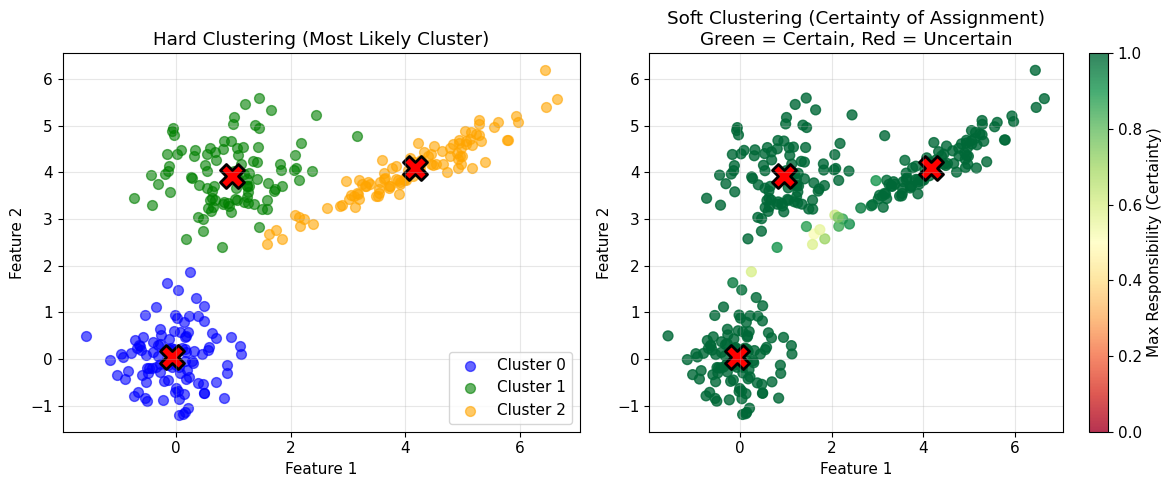


Most uncertain points (could belong to multiple clusters):
Point [1.61322676 2.67517463]: responsibilities = [4.85913462e-06 4.90829335e-01 5.09165806e-01]
Point [1.74089714 2.76888236]: responsibilities = [9.51944578e-07 4.38605071e-01 5.61393977e-01]
Point [1.58058391 2.45220528]: responsibilities = [4.12271202e-05 4.14615834e-01 5.85342939e-01]
Point [0.24653884 1.86717251]: responsibilities = [0.59388095 0.32334376 0.08277528]
Point [2.06808457 3.08065586]: responsibilities = [6.90377890e-09 3.75306316e-01 6.24693677e-01]


In [21]:
# Compute max responsibility for each point (certainty)
max_responsibilities = final_responsibilities.max(axis=1)

# Points with low max responsibility are uncertain (sit between clusters)
hard_labels = np.argmax(final_responsibilities, axis=1)

plt.figure(figsize=(12, 5))

# Left: colored by cluster
ax1 = plt.subplot(1, 2, 1)
for i in range(k):
    cluster_points = X[hard_labels == i]
    ax1.scatter(cluster_points[:, 0], cluster_points[:, 1],
               alpha=0.6, s=50, c=colors[i], label=f'Cluster {i}')
ax1.scatter(final_means[:, 0], final_means[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Hard Clustering (Most Likely Cluster)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: colored by certainty
ax2 = plt.subplot(1, 2, 2)
scatter = ax2.scatter(X[:, 0], X[:, 1], c=max_responsibilities, 
                     cmap='RdYlGn', s=50, alpha=0.8, vmin=0, vmax=1)
ax2.scatter(final_means[:, 0], final_means[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2)
plt.colorbar(scatter, ax=ax2, label='Max Responsibility (Certainty)')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Soft Clustering (Certainty of Assignment)\nGreen = Certain, Red = Uncertain')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find most uncertain points
uncertain_indices = np.argsort(max_responsibilities)[:5]
print("\nMost uncertain points (could belong to multiple clusters):")
for idx in uncertain_indices:
    print(f"Point {X[idx]}: responsibilities = {final_responsibilities[idx]}")

**Key insight:** 
- Points in cluster centers are **certain** (green, high responsibility)
- Points between clusters are **uncertain** (red, low max responsibility)
- This uncertainty information is **lost** in k-means!
- Applications: anomaly detection, active learning (query uncertain points)

## 17. Practical Considerations

### When to Use GMMs

**Advantages over k-means:**
- Soft clustering: probabilistic assignments with uncertainty
- Flexible shapes: elliptical clusters via covariance
- Principled statistics: proper likelihood-based framework
- Generative model: can sample new data from learned distribution

**Disadvantages:**
- More parameters → needs more data
- Slower: computing Gaussians is more expensive than distances
- Can get stuck in local optima (like k-means)
- Assumes Gaussian clusters (may not fit all data)

**Best practices:**
1. **Try multiple initializations** (k-means++ works for GMMs too)
2. **Use BIC/AIC** to choose $k$ instead of elbow method
3. **Start with simpler covariance** (spherical/diagonal) if you have limited data
4. **Normalize features** if they have different scales
5. **Check for singularities**: add regularization to covariances

## 18. Key Takeaways

### What We Learned

**Core Algorithm:**
- GMMs model data as a mixture of Gaussians with soft assignments
- EM alternates between computing responsibilities (E-step) and updating parameters (M-step)
- Guaranteed to converge by monotonically increasing log-likelihood

**Soft vs Hard Clustering:**
- **K-means**: Each point belongs to exactly one cluster (hard)
- **GMM**: Each point has probabilities for all clusters (soft)
- Soft assignments capture uncertainty — crucial for real-world data

**Covariance Types:**
- **Spherical**: Circles — fastest, fewest parameters
- **Diagonal**: Axis-aligned ellipses — moderate complexity
- **Full**: Arbitrary ellipses — most flexible, most parameters

**Model Selection:**
- Can't use raw likelihood (always increases with $k$)
- BIC and AIC penalize complexity: $\text{Score} = -2\log L + \text{penalty}$
- Lower is better; BIC prefers simpler models than AIC

**Connection to K-Means:**
- K-means is GMM with spherical covariance → 0
- GMM generalizes k-means with probabilistic framework
- EM generalizes k-means' assignment-update loop

**Intuition:**
The world is rarely black and white — points near cluster boundaries shouldn't be forced into one category. GMMs embrace the gray area by modeling membership as a **probability distribution**, giving us both predictions and confidence!